In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcc2Frc2hcRG9jdW1lbnRzXGNvZGUtcmVwb1xwZXJzb25hbC13ZWJzaXRlXHRpZGJpdHNcaGFybW9uaWMtb3NjaWxsYXRvci10aGVybWFsLXN0YXRlLTE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| output: false
begin
    using Pkg
    Pkg.activate("./")
    using Plots, DataFrames, JSON
end

  Activating project at `C:\Users\saksh\Documents\code-repo\personal-website\tidbits\harmonic-oscillator-thermal-state-1`


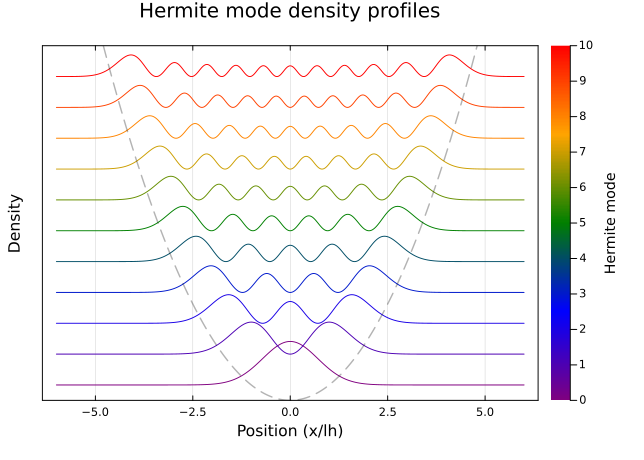

In [3]:
begin
    # efficient computation of Hermite functions using recurrence relations
    function hermite(n, x)
        iszero(n) && return (π)^(-0.25) * exp(-x^2 / 2)
        isone(n) && return sqrt(2) * x * π^(-0.25) * exp(-x^2 / 2)

        hi, hj = hermite(1, x), hermite(0, x)

        for k in 2:n
            hj = sqrt(2 / k) * x * hi - sqrt((k - 1) / k) * hj
            hi, hj = hj, hi
        end

        return hi
    end

    ns = 0:10
    xs = -6:0.01:6
    plot(xs, 2.5 * hermite.(ns', xs) .^ 2 .+ ns' .+ 0.5, lab="", line_z=ns', color=:rainbow)
    plot!(x -> 0.5 * x^2, xs, c=:black, lw=1.5, ls=:dash, alpha=0.3, lab="")
    plot!(framestyle=:box, ylim=[0, last(ns) * 1.15], yticks=nothing, xlabel="Position (x/lh)", colorbartitle="Hermite mode", title="Hermite mode density profiles", ylabel="Density", margins=5Plots.mm)
end